<a href="https://colab.research.google.com/github/pressleydavid/hw4/blob/main/HW4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Summarizing Student Data Graphically

## Task 1: Read in the data

*   Copy code and markdown cells from homework 3 that read in the data and summarized it numerically.

In [59]:
import pandas as pd
url = "https://www4.stat.ncsu.edu/~online/datasets/StudentData.txt"
student_data = pd.read_csv(url, delimiter=';')

# quick checks
student_data.shape
student_data.head()
student_data.info()
student_data.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

### Categorical Variables

#### Stacked Bar Chart

Sex DType Before astype: category
Sex DType after astype: category
School DType Before astype: category
School DType after astype: category
Sex categories before rename: Index(['Female', 'Male'], dtype='object')
Sex categories after rename: Index(['Female', 'Male'], dtype='object')
School categories before rename: Index(['Gabriel Pereira', 'Mousinho da Silveira'], dtype='object')
School categories after rename: Index(['Gabriel Pereira', 'Mousinho da Silveira'], dtype='object')


Sex,Female,Male
School,,
Gabriel Pereira,183,166
Mousinho da Silveira,25,21


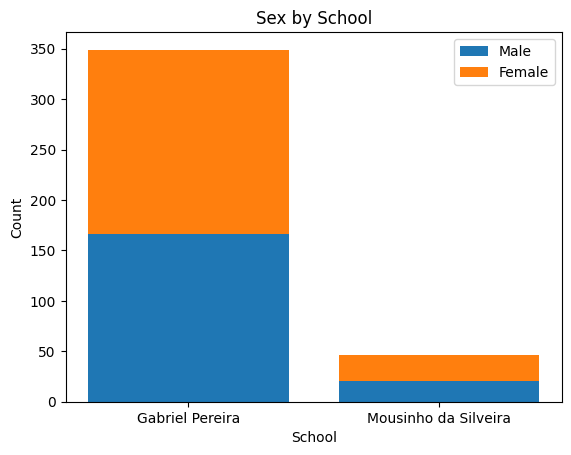

In [77]:
import pandas as pd
import matplotlib.pyplot as plt


print(f"Sex DType Before astype: {student_data.sex.dtype}")
student_data["sex"] = student_data["sex"].astype("category")
print(f"Sex DType after astype: {student_data.sex.dtype}")

print(f"School DType Before astype: {student_data.school.dtype}")
student_data["school"] = student_data["school"].astype("category")
print(f"School DType after astype: {student_data.school.dtype}")

print(f"Sex categories before rename: {student_data.sex.cat.categories}")
student_data["sex"] = student_data["sex"].cat.rename_categories({"F":"Female", "M":"Male"})
print(f"Sex categories after rename: {student_data.sex.cat.categories}")

print(f"School categories before rename: {student_data.school.cat.categories}")
student_data["school"] = student_data["school"].cat.rename_categories({"GP":"Gabriel Pereira", "MS":"Mousinho da Silveira"})
print(f"School categories after rename: {student_data.school.cat.categories}")

stacked_school_table = pd.crosstab(student_data.school, student_data.sex, rownames=["School"], colnames=["Sex"])

display(stacked_school_table)

#get rows for Female
stacked_school_table.loc[:, "Female"]
stacked_school_table.loc[:, "Male"]

#plot stacked bar graph
plt.bar(
    x = student_data.school.cat.categories,
    height = stacked_school_table.loc[:,"Male"],
    label = "Male"
)
plt.bar(
    x = student_data.school.cat.categories,
    height = stacked_school_table.loc[:,"Female"],
    bottom = stacked_school_table.loc[:,"Male"],
    label = "Female"
)
plt.title("Sex by School")
plt.xlabel("School")
plt.ylabel("Count")
plt.legend(loc = 0)
plt.show()
plt.close()





##### Discussion
The stacked bar shows the gender breakdown at each school. Gabriel Pereira is the larger school and has more students of both sexes. The gender split is about the same at both schools. From a statistical comparison perspective since GP has significantly more students, any school-level comparisons should keep unequal sample sizes in mind.

#### Side-by-Side Bar Chart

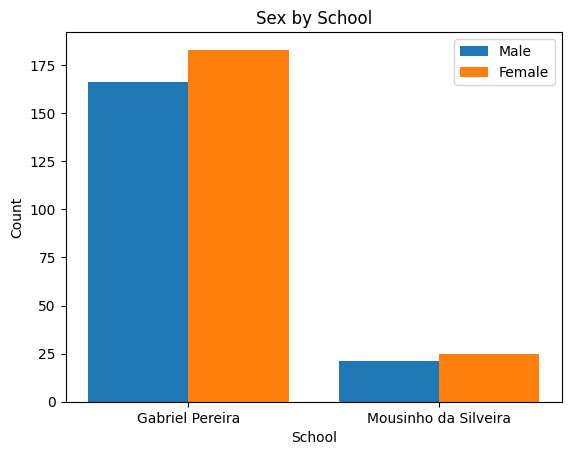

In [62]:
#plot side-by-side bar graph

plt.bar(
    x = [1, 2],
    # student_data.school.cat.categories,
    height = stacked_school_table.loc[:,"Male"],
    width=0.4,
    label = "Male"
)
plt.bar(
    # x = ["Male", "Female"],
    x = [1.4, 2.4],
    # student_data.school.cat.categories,
    height = stacked_school_table.loc[:,"Female"],
    width = 0.4,
    label = "Female"
)
index = ["Female","Male"]
stacked_school_table[index]
plt.xticks([1.2, 2.2], student_data.school.cat.categories)
plt.title("Sex by School")
plt.xlabel("School")
plt.ylabel("Count")
plt.legend(loc = 0)
plt.show()
plt.close()

##### Discussion
The side-by-side view makes it easier to directly compare the balance of male vs female counts within each school than the stacked version. Comparisons by gender are well balanced, but comparisons across schools are significantly different

## Numeric Variable Distributions Across Groups

Create visualizations (histogram, kernel density plot, and boxplot) for two numeric variables grouped by a categorical variable to compare distributions.
 Overlay at least one kernel density plot across groups and include appropriate labels and titles for all graphs.



#### Setup data by subsetting `G3`, `studytime`, and `absences`

In [63]:
from re import sub
import pandas as pd
import matplotlib.pyplot as plt

# subset the student_data by selecting the desired columns
# .copy() to create an independent DataFrame instead of a view (prevents SettingWithCopyWarning)
sub_student_data = student_data[["G3", "G1", "famrel", "studytime", "absences", "health"]].copy()
display(sub_student_data.head())
display(sub_student_data.G3.unique())

# check for continuous
print(f"Unique values before conversion: {sub_student_data.studytime.unique()}")

# discrete. convert to category
sub_student_data["studytime"] = sub_student_data["studytime"].astype("category")

print(f"Dtype after conversion: {sub_student_data['studytime'].dtype}")

# apply labels for studytime
## find category order
print(f"studytime category order before renaming categories: {sub_student_data.studytime.cat.categories}")
sub_student_data.studytime = sub_student_data.studytime.cat.rename_categories(["<2 hours", "2 to 5 hours", "5 to 10 hours", ">10 hours"])
print(f"studytime category order after renaming categories: {sub_student_data.studytime.cat.categories}")



,G3,G1,famrel,studytime,absences,health
0,6,5,4,2,6,3
1,6,5,5,2,4,3
2,10,7,4,2,10,3
3,15,15,3,3,2,5
4,10,6,4,2,4,5


array([ 6, 10, 15, 11, 19,  9, 12, 14, 16,  5,  8, 17, 18, 13, 20,  7,  0,
        4])

Unique values before conversion: [2 3 1 4]
Dtype after conversion: category
studytime category order before renaming categories: Index([1, 2, 3, 4], dtype='int64')
studytime category order after renaming categories: Index(['<2 hours', '2 to 5 hours', '5 to 10 hours', '>10 hours'], dtype='object')


### Final Grade (G3) by Study Time

#### Histogram: G3 by Study Time

[0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 20.0]


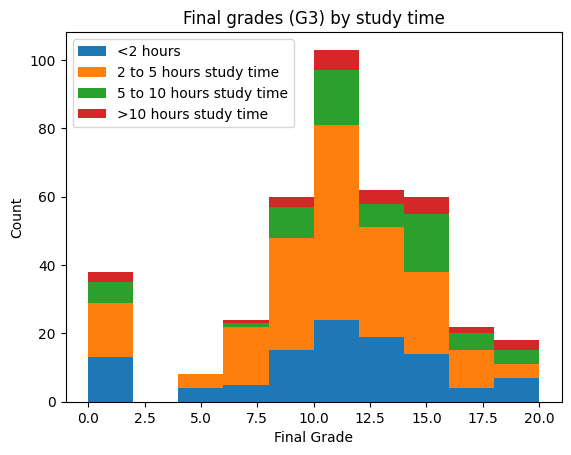

In [64]:
# Bins
bin_ends = 10
bins = [i*max(sub_student_data.G3)/bin_ends for i in range(0, bin_ends + 1)]
print(bins)

# Subset G3 scores where studytime is "<2 hours" (originally value 1)
g3_studytime1 = sub_student_data.loc[sub_student_data["studytime"] == "<2 hours", "G3"]

# Subset G3 scores where studytime is "2 to 5 hours" (originally value 2)
g3_studytime2 = sub_student_data.loc[sub_student_data["studytime"] == "2 to 5 hours", "G3"]
# g3_studytime2

# Subset G3 scores where studytime is "5 to 10 hours" (originally value 3)
g3_studytime3 = sub_student_data.loc[sub_student_data["studytime"] == "5 to 10 hours", "G3"]
# g3_studytime3

# Subset G3 scores where studytime is ">10 hours" (originally value 4)
g3_studytime4 = sub_student_data.loc[sub_student_data["studytime"] == ">10 hours", "G3"]
# g3_studytime4

# Histogram
plt.hist(
    [g3_studytime1, g3_studytime2, g3_studytime3, g3_studytime4],
    bins=bins,
    stacked=True,
    label=["<2 hours", "2 to 5 hours study time", "5 to 10 hours study time", ">10 hours study time"]
)
plt.legend()
plt.title("Final grades (G3) by study time")
plt.xlabel("Final Grade")
plt.ylabel("Count")
plt.show()

##### Discussion
The histogram shows that there aren't as many students studying less than 2 hours, but have a noticeable count of zeros (students who scored 0 on the final). The 2-to-5 hour group is the largest and shows a roughly normal distribution centered around 10-12. Students in the higher study time groups tend to have fewer very low scores, but sample sizes get much smaller for the 5-10 and >10 hour groups, making it harder to draw firm conclusions.

#### Kernel Density Plot: G3 by Study Time (Overlaid)

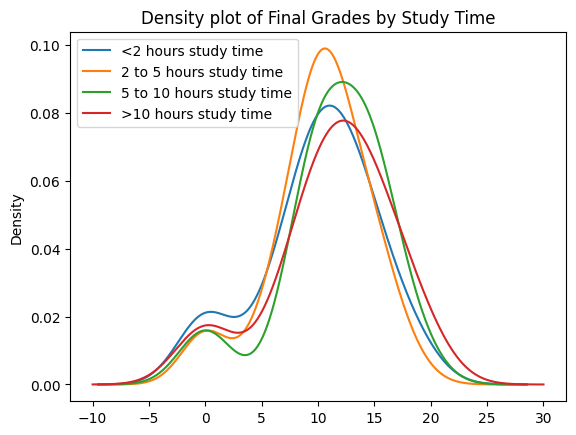

In [65]:
g3_studytime1.plot.density(bw_method = 0.5, alpha = 1.0, label="<2 hours study time")
g3_studytime2.plot.density(bw_method = 0.5, alpha = 1.0, label="2 to 5 hours study time")
g3_studytime3.plot.density(bw_method = 0.5, alpha = 1.0, label="5 to 10 hours study time")
g3_studytime4.plot.density(bw_method = 0.5, alpha = 1.0, label=">10 hours study time")
plt.legend()
plt.title("Density plot of Final Grades by Study Time")
plt.show()


##### Discussion
The density curves confirm the histogram pattern. All groups have a bump near 0 for the final grade. The 2-5 hour and 5-10 hour curves peak at similar locations. The >10 hours group shows a small peak at higher grades, which is lower than every other group. :

#### Boxplot: G3 by Study *Time*

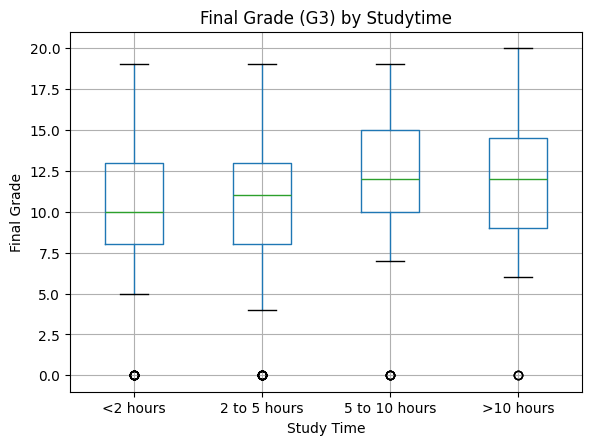

In [66]:
sub_student_data.boxplot(column = ["G3"], by = "studytime")

# Suppress the automatic title
plt.suptitle("")

# Set the desired chart title
plt.title("Final Grade (G3) by Studytime")
plt.xlabel("Study Time")
plt.ylabel("Final Grade")
plt.show()

##### Discussion
The boxplots show unremarkable differences in center and spread, but the median trends moderately higher across study time groups. Comparing the 5-10 and >10 hour groups, there is a little more spread across the >10 hour group due to the lower sample sizes, so the box is somewhat wider. On the whole, across the dataset, they show good balance


### Absences by Study Time

#### Histogram: Absences by Study Time


[0.0, 7.5, 15.0, 22.5, 30.0, 37.5, 45.0, 52.5, 60.0, 67.5, 75.0]


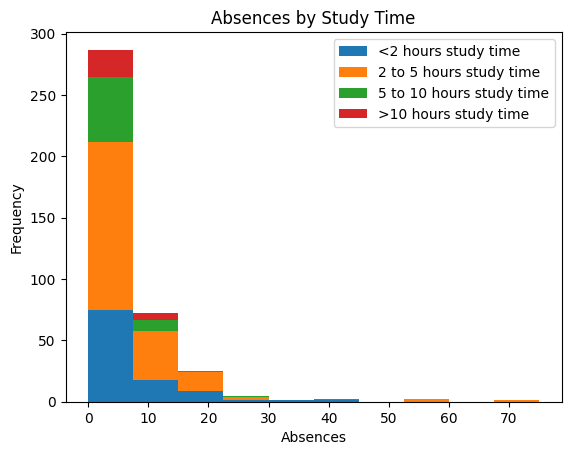

In [67]:
# Bins
bin_ends = 10
bins = [i*max(sub_student_data.absences)/bin_ends for i in range(0, bin_ends + 1)]
print(bins)

# Subset absences where studytime is "<2 hours" (originally value 1)
ab_studytime1 = sub_student_data.loc[sub_student_data["studytime"] == "<2 hours", "absences"]

# Calculate and print the statistical range
# range_1 = ab_studytime1.max() - ab_studytime1.min()
# print(f"Statistical Range for <2 hours study time: {range_1}")

# Subset absences where studytime is "2 to 5 hours" (originally value 2)
ab_studytime2 = sub_student_data.loc[sub_student_data["studytime"] == "2 to 5 hours", "absences"]
# g3_studytime2

# Subset absences where studytime is "5 to 10 hours" (originally value 3)
ab_studytime3 = sub_student_data.loc[sub_student_data["studytime"] == "5 to 10 hours", "absences"]
# g3_studytime3

# Subset absences where studytime is ">10 hours" (originally value 4)
ab_studytime4 = sub_student_data.loc[sub_student_data["studytime"] == ">10 hours", "absences"]
# g3_studytime4

# Histogram
# sub_student_data.plot.hist(bins = bins, alpha = 1.0, label="Absences", title = "Absences by Study Time")
plt.hist(
    [ab_studytime1, ab_studytime2, ab_studytime3, ab_studytime4],
    bins=bins,
    stacked=True,
    label=["<2 hours study time", "2 to 5 hours study time", "5 to 10 hours study time", ">10 hours study time"]
)
plt.legend()
plt.title("Absences by Study Time")
plt.xlabel("Absences")
plt.ylabel("Frequency")
plt.show()

##### Discussion
All study time groups show a strong right skew in absences, indicating students have few absences regardless of how much they study. Most study time groups have between 0 and 10. The two highest study time groups have most of their near zero absences. This seems reasonable. Students who study more may also be more likely to attend class regularly.

#### Kernel Density Plot: Absences by Study Time

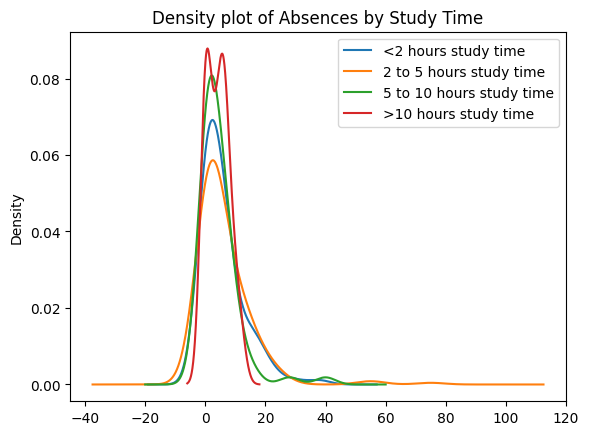

In [68]:
ab_studytime1.plot.density(bw_method = 0.5, alpha = 1.0, label="<2 hours study time",title = "Absences for students who studied less than 2 hours")
ab_studytime2.plot.density(bw_method = 0.5, alpha = 1.0, label="2 to 5 hours study time",title = "Absences for students who studied 2 to 5 hours")
ab_studytime3.plot.density(bw_method = 0.5, alpha = 1.0, label="5 to 10 hours study time",title = "Absences for students who studied 5 to 10 hours")
ab_studytime4.plot.density(bw_method = 0.5, alpha = 1.0, label=">10 hours study time")
plt.legend()
plt.title("Density plot of Absences by Study Time")
plt.show()

##### Discussion
The density curves reflect the skewed nature of absence data from the histogram. The <2 hours group has a slightly flatter peak and heavier tail than the others, suggesting more variability in attendance for students who study the least. All curves are very similar in shape, and tend to be centered around zero absences.

#### Boxplot: Absences by Study Time

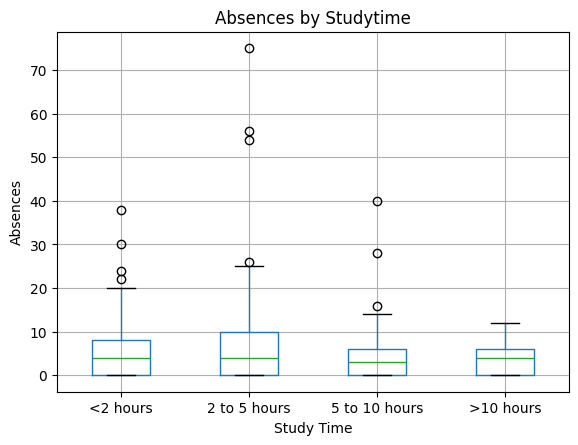

In [69]:
sub_student_data.boxplot(column = ["absences"], by = "studytime")

# Suppress the automatic title
plt.suptitle("")

# Set the desired chart title
plt.title("Absences by Studytime")
plt.xlabel("Study Time")
plt.ylabel("Absences")
plt.show()

##### Discussion
The boxplots medians are low across all groups (roughly 2-6 absences) with many upper outliers. The outliers here are interesting and likely influential observations, since the requirement for school attendance is likely mandated by the state and there are similar numbers of outliers across groups


#### Scatterplot of Absences and Final Grade by Health

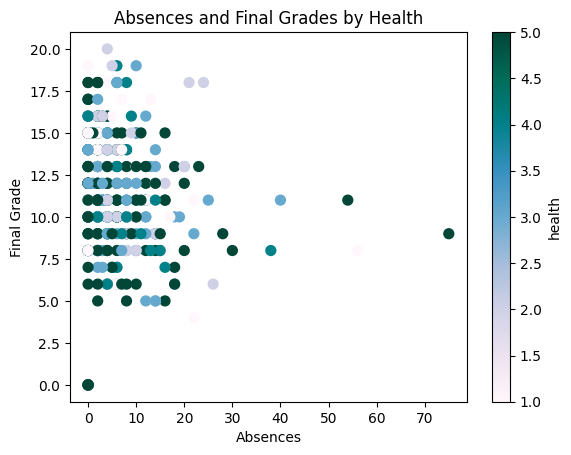

In [70]:
sub_student_data.plot.scatter(x = "absences", y = "G3", c = "health", cmap = "PuBuGn", s =50)
plt.xlabel("Absences")
plt.ylabel("Final Grade")
plt.title("Absences and Final Grades by Health")
plt.show()

##### Discussion
There's no strong linear relationship between absences and final grade. Students across the board achieve both high and low grades. The health coloring doesn't reveal an obvious pattern either; students in poor and good health are scattered throughout, suggesting absences as a result of sickness may not be a predictor of final grade.

#### Scatterplot of Initial Grade and Final Grade by Family Relationship Quality

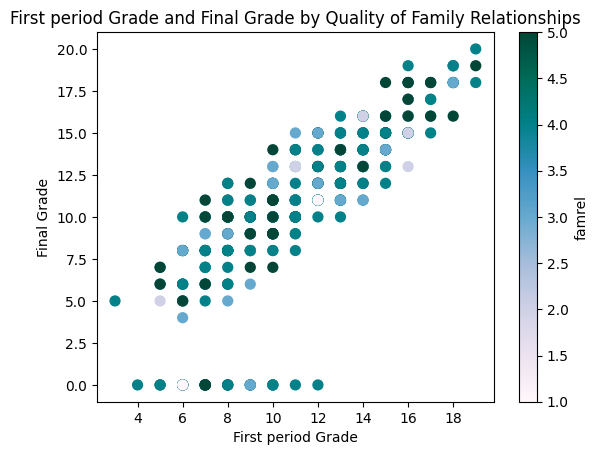

In [71]:
sub_student_data.plot.scatter(x = "G1", y = "G3", c = "famrel", cmap = "PuBuGn", s = 50)
plt.title("First period Grade and Final Grade by Quality of Family Relationships")
plt.xlabel("First period Grade")
plt.ylabel("Final Grade")
plt.show()

##### Discussion
This shows a strong positive linear relationship between first period grade and final grade suggesting students who do well early tend to do well at the end. The family relationship coloring doesn't show clear separation of concerns. Students with high and low family relationship quality exist at all grade levels. There is an interesting cluster at the bottom that represents students with G1 scores, but not final G3 scores. One possibility is that these may be dropouts rather than students who simply performed poorly.



---
---
---



# Plotting the NFL Data

## Strategy

### Task 1: Read in Data

* Import the dataset from a URL or download it locally
* Convert specific columns (homeTeam, awayTeam, day, stadium, startTime, toss, roof, and surface) to categorical variables
* Review the first few rows of the dataset



In [72]:
import pandas as pd

url = "https://www4.stat.ncsu.edu/~online/datasets/scoresFull.csv"

nfl_src = pd.read_csv(url)
nfl_src.head()
nfl_src.info()
nfl_src.shape
nfl_src.columns.tolist()
nfl_src["week"].unique()

# make a copy for manipulation
nfl_intermed = nfl_src.copy()

# convert vars to category dtype
def convert_to_category(*args):
    for i in convert_list:
        print(f"Before converstion: var: {nfl_src[i].name} dtype: {nfl_src[i].dtype}")
        nfl_intermed[i+"C"] = nfl_src[i].astype("category")
        print(f"After conversion: var: {nfl_intermed[i+"C"].name} dtype: {nfl_intermed[i+"C"].dtype}")
    return None

convert_list = ["homeTeam","awayTeam","day","stadium","startTime","toss", "roof", "surface"]
convert_to_category(convert_list)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3471 entries, 0 to 3470
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   week             3471 non-null   object 
 1   date             3471 non-null   object 
 2   day              3471 non-null   object 
 3   season           3471 non-null   int64  
 4   awayTeam         3471 non-null   object 
 5   AQ1              3471 non-null   int64  
 6   AQ2              3471 non-null   int64  
 7   AQ3              3471 non-null   int64  
 8   AQ4              3471 non-null   int64  
 9   AOT              3471 non-null   int64  
 10  AOT2             3471 non-null   int64  
 11  AFinal           3471 non-null   int64  
 12  homeTeam         3471 non-null   object 
 13  HQ1              3471 non-null   int64  
 14  HQ2              3471 non-null   int64  
 15  HQ3              3471 non-null   int64  
 16  HQ4              3471 non-null   int64  
 17  HOT           

### Task 2: Summarize the Data

#### Numeric Summaries
*   filter for regular season weeks


In [73]:
# filter for regular season
print(f"Unique week values before filter {nfl_intermed.week.unique()}")

regular_weeks = [str(i) for i in range(1,18)]

nfl_intermed = nfl_intermed.loc[nfl_intermed["week"].isin(regular_weeks), :]
print(f"Unique week values after filter {nfl_intermed.week.unique()}")

nfl_intermed.week.unique()

nfl_intermed["weekN"] = nfl_intermed["week"].astype(int)
nfl_intermed.weekN.unique()

# summarize by season and week
nfl_intermed.info()
reg_season= nfl_intermed.copy()
reg_season = reg_season.loc[:,["season","weekN","AtotalYds","tossC","awayFum","home3rdConv","away3rdConv","awayTimesSacked","homeTimesSacked"]]

# group Away total yard statsby season and numerical week (1-17)
display(reg_season.groupby(["season", "weekN"]).agg(
    max_yds = ("AtotalYds", "max"),
    min_yds = ("AtotalYds", "min"),
    mean_yds = ("AtotalYds", "mean")
).round(2))

# group Away total yard stats by season
display(reg_season.groupby(["season"]).agg(
    max_yds = ("AtotalYds", "max"),
    min_yds = ("AtotalYds", "min"),
    mean_yds = ("AtotalYds", "mean")
).round(2))

# group Away total yard stats by week (numeric: 1 - 17)
display(reg_season.groupby(["weekN"]).agg(
    max_yds = ("AtotalYds", "max"),
    min_yds = ("AtotalYds", "min"),
    mean_yds = ("AtotalYds", "mean")
).round(2))


# group Away fumble stats by season and numerical week (1-17)

display(reg_season.groupby(["season", "weekN"]).agg(
    max_fumA = ("awayFum", "max"),
    min_fum = ("awayFum", "min"),
    mean_fum = ("awayFum", "mean")
).round(2))

# group Away fumble stats by season

display(reg_season.groupby(["season"]).agg(
    max_fum = ("awayFum", "max"),
    min_fum = ("awayFum", "min"),
    mean_fum = ("awayFum", "mean")
).round(2))

# group Away fumble stats by week (numeric: 1 - 17)
display(reg_season.groupby(["weekN"]).agg(
    max_fum = ("awayFum", "max"),
    min_fum = ("awayFum", "min"),
    mean_fum = ("awayFum", "mean")
).round(2))


Unique week values before filter ['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15' '16'
 '17' 'WildCard' 'Division' 'ConfChamp' 'SuperBowl']
Unique week values after filter ['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15' '16'
 '17']
<class 'pandas.core.frame.DataFrame'>
Index: 3328 entries, 0 to 3459
Data columns (total 91 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   week             3328 non-null   object  
 1   date             3328 non-null   object  
 2   day              3328 non-null   object  
 3   season           3328 non-null   int64   
 4   awayTeam         3328 non-null   object  
 5   AQ1              3328 non-null   int64   
 6   AQ2              3328 non-null   int64   
 7   AQ3              3328 non-null   int64   
 8   AQ4              3328 non-null   int64   
 9   AOT              3328 non-null   int64   
 10  AOT2             3328 non-null   int64   
 11  AFinal       

max_yds  min_yds  mean_yds
season weekN                            
2002   1          470      186    310.00
       2          468      118    340.94
       3          442      145    299.21
       4          443      240    344.07
       5          504      245    379.57
...               ...      ...       ...
2014   13         464      244    346.38
       14         543      233    392.44
       15         443      245    327.38
       16         596      211    368.62
       17         494      199    330.69

[221 rows x 3 columns]

,max_yds,min_yds,mean_yds
season,,,
2002,591,47,324.20
2003,548,96,306.58
2004,605,26,320.58
2005,494,113,307.97
2006,536,104,316.63
2007,531,104,322.85
2008,564,125,319.44
2009,524,72,323.10
2010,592,67,329.39


,max_yds,min_yds,mean_yds
weekN,,,
1,622,120,320.74
2,539,118,314.98
3,583,118,332.66
4,580,110,332.79
5,517,124,330.95
6,605,149,337.96
7,518,134,329.10
8,521,104,320.23
9,542,104,335.89


max_fumA  min_fum  mean_fum
season weekN                             
2002   1             3        0      1.25
       2             3        0      1.44
       3             4        0      1.79
       4             4        0      1.64
       5             4        0      1.57
...                ...      ...       ...
2014   13            5        0      1.38
       14            4        0      1.25
       15            4        0      1.50
       16            2        0      0.75
       17            2        0      0.94

[221 rows x 3 columns]

,max_fum,min_fum,mean_fum
season,,,
2002,7,0,1.59
2003,6,0,1.51
2004,6,0,1.51
2005,7,0,1.60
2006,6,0,1.48
2007,8,0,1.61
2008,6,0,1.45
2009,7,0,1.44
2010,7,0,1.44


,max_fum,min_fum,mean_fum
weekN,,,
1,7,0,1.62
2,6,0,1.51
3,5,0,1.42
4,5,0,1.45
5,4,0,1.37
6,7,0,1.45
7,6,0,1.64
8,6,0,1.39
9,5,0,1.27


##### Discussion
These three groupby summaries show away total yards and away fumbles across different aggregation levels.
* By season and week, there's some game-to-game variability:
    - the max away yardage in a single game can exceed 600 yards while the min can be under 100
    - Aggregating by season alone smooths this out, showing mean away yardage has been relatively stable around 310-330 yards across the 2002-2014 period
    - The week-level summary shows no strong trend across the season as away yardage doesn't seem to increase or decrease as the season progresses.
* Fumble rates are low on average (around 1 per game) and fairly consistent across both seasons and weeks.

#### Time series plots

,weekN,mean_h3rd_conv_by_week,mean_a3rd_conv_by_week
0,1,3.59,3.50
1,2,3.91,3.39
2,3,3.79,3.54
3,4,3.86,3.34
4,5,3.68,3.49
5,6,3.72,3.76
6,7,3.61,3.54
7,8,3.75,3.51
8,9,3.80,3.63
9,10,3.69,3.40


,season,mean_h3rd_conv_by_season,mean_a3rd_conv_by_season
0,2002,3.00,2.80
1,2003,2.67,2.34
2,2004,2.54,2.44
3,2005,2.70,2.44
4,2006,2.69,2.74
5,2007,2.79,2.53
6,2008,2.67,2.65
7,2009,2.86,2.52
8,2010,5.14,5.08
9,2011,5.14,4.93


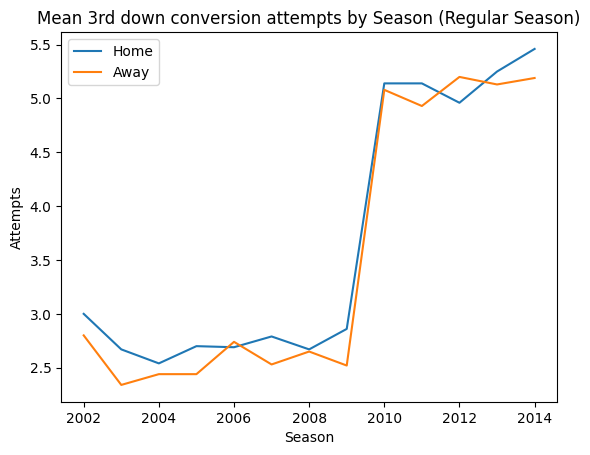

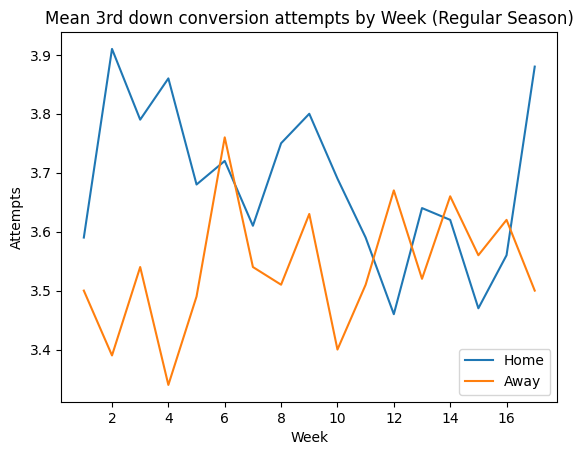

In [74]:

#home3rdConv
#away3rdConv
#awayTimesSacked
#homeTimesSacked

reg_season_plots = reg_season.loc[:,["season","weekN","home3rdConv","away3rdConv","awayTimesSacked","homeTimesSacked"]].copy()

# get the data types of all columns in the DataFrame
# reg_season_plots.dtypes

#get info
# reg_season_plots.info()


#plot home and away 3rd down conversion by season and week
#by season
third_down_conv_summ_by_season = reg_season_plots.groupby(["season"]).agg(
    mean_h3rd_conv_by_season = ("home3rdConv", "mean"),
    mean_a3rd_conv_by_season  = ("away3rdConv", "mean")
).round(2).reset_index()

#by week
third_down_conv_summ_by_week = reg_season_plots.groupby(["weekN"]).agg(
    mean_h3rd_conv_by_week = ("home3rdConv", "mean"),
    mean_a3rd_conv_by_week = ("away3rdConv", "mean")
).round(2).reset_index()

display(third_down_conv_summ_by_week)
display(third_down_conv_summ_by_season)

#by season
third_down_conv = third_down_conv_summ_by_season.plot.line(x = "season", y = ["mean_h3rd_conv_by_season","mean_a3rd_conv_by_season"]).legend(["Home","Away"])
plt.title("Mean 3rd down conversion attempts by Season (Regular Season)")
plt.xlabel("Season")
plt.ylabel("Attempts")
plt.show()
plt.close()

#by week
third_down_conv = third_down_conv_summ_by_week.plot.line(x = "weekN", y = ["mean_h3rd_conv_by_week","mean_a3rd_conv_by_week"]).legend(["Home","Away"])
plt.title("Mean 3rd down conversion attempts by Week (Regular Season)")
plt.xlabel("Week")
plt.ylabel("Attempts")
plt.show()
plt.close()



##### Discussion
Mean 3rd down conversions were calculated across regular season weeks and seasons from 2002 to 2014.

For the conversion attempts by season, there was a significant jump in the 2009 season for 3rd down attempts.


For the conversion attempts by week, it seems the homefield advantage comes into play as the home team has significantly more attempts until about week 10, then the away teams close the gap a bit

#### Plotting Function





Team: San Francisco 49ers
Analysis Column: homeTimesSacked
Group By: season
Stat: mean


,season,grouped_stat
0,2002,1.88
1,2003,1.94
2,2004,2.88
3,2005,2.00
4,2006,2.06
5,2007,2.62
6,2008,1.75
7,2009,2.75
8,2010,1.94
9,2011,2.00


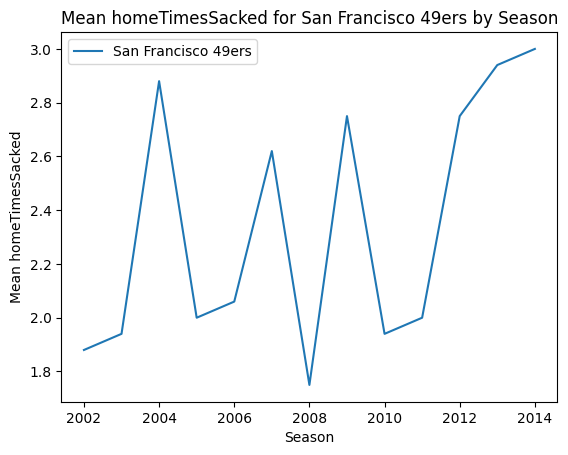

line_plotter ran in 0.181981 seconds
Team: Seattle Seahawks
Analysis Column: home3rdConv
Group By: season
Stat: mean


,season,grouped_stat
0,2002,3.19
1,2003,3.69
2,2004,2.88
3,2005,3.00
4,2006,3.38
5,2007,2.94
6,2008,2.25
7,2009,3.00
8,2010,5.44
9,2011,5.56


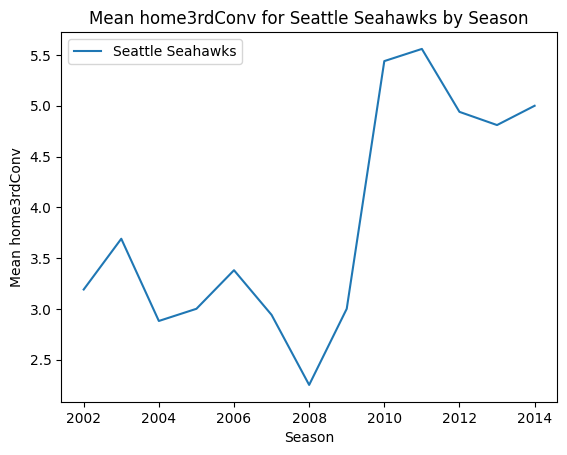

line_plotter ran in 0.188446 seconds
Team: Detroit Lions
Analysis Column: awayTimesSacked
Group By: weekN
Stat: mean


,weekN,grouped_stat
0,1,2.54
1,2,3.15
2,3,2.58
3,4,2.82
4,5,2.73
5,6,2.55
6,7,1.91
7,8,1.58
8,9,2.50
9,10,1.77


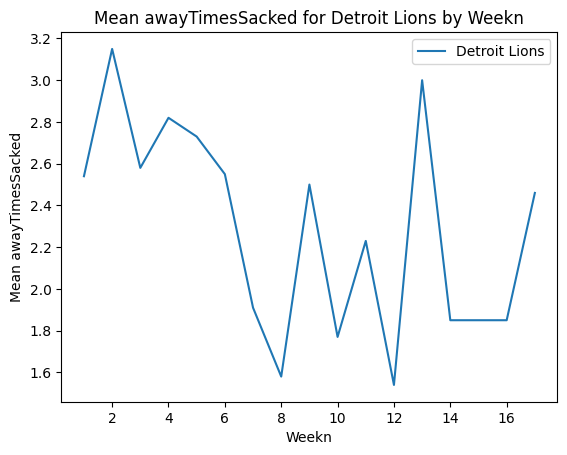

line_plotter ran in 0.193374 seconds
Team: Las Vegas Raiders
Analysis Column: homeTeam
Group By: season
Stat: mean
homeTeam is not numeric. Unable to plot.
line_plotter ran in 0.000795 seconds


In [75]:
import matplotlib.pyplot as plt
import time
from functools import wraps

def timeit(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        start = time.perf_counter()
        result = func(*args, **kwargs)
        end = time.perf_counter()
        elapsed = end - start
        print(f"{func.__name__} ran in {elapsed:.6f} seconds")
        return result
    return wrapper

fxn_plots = nfl_intermed.loc[:,["season","weekN","home3rdConv","away3rdConv","awayTimesSacked","homeTimesSacked", "homeTeam", "awayTeam"]].copy()

@timeit
def line_plotter(df: pd.DataFrame,
                 team: str = "San Francisco 49ers",
                 col: str = "homeTimesSacked",
                 group: str = "season",
                 stat: str = "mean",
                 **kwargs):
    """
    Generates a line plot for a given numeric variable over a specified grouping variable.

    Args:
        df (pd.DataFrame): The DataFrame containing the data
        team (str): The name of the team to filter by.
        col (str): The name of the column to analyze (numeric).
        group (str): The name of the column to group by (e.g., 'season', 'weekN').
        stat (str): The statistical aggregation to apply ('mean', 'max', 'min', etc.).
        **kwargs: Additional keyword arguments for future enhancements.

    """

    print(f"Team: {team}\nAnalysis Column: {col}\nGroup By: {group}\nStat: {stat}")

    numeric_cols = df.select_dtypes(include="number").columns.tolist()
    # print(f"Numeric Cols: {numeric_cols}")

    if col not in numeric_cols:
        print(f"{col} is not numeric. Unable to plot.")
        return

    # Filter the DataFrame for the specified team before grouping
    # Assume 'team' refers to either homeTeam or awayTeam for simplicity.
    filtered_df = df[(df['homeTeam'] == team) | (df['awayTeam'] == team)].copy()

    if filtered_df.empty:
        print(f"No data found for team: {team}")
        return

    # Use the filtered DataFrame for aggregation
    by_group_stat = filtered_df.groupby([str(group)]).agg(grouped_stat = (str(col), str(stat))).round(2).reset_index()

    display(by_group_stat)

    # Plot
    fxnPlot = by_group_stat.plot.line(x = str(group), y = "grouped_stat")
    plt.title(f"{stat.capitalize()} {col} for {team} by {group.capitalize()}")
    plt.xlabel(f"{group.capitalize()}")
    plt.ylabel(f"{stat.capitalize()} {col}")
    plt.legend([f"{team}"], loc = 'best')
    plt.show()
    plt.close()

    return None

# Call the function, passing fxn_plots as the DataFrame

# Call 1
line_plotter(fxn_plots, team="San Francisco 49ers", col="homeTimesSacked", group="season", stat="mean")

# Call 2
line_plotter(fxn_plots, team = "Seattle Seahawks", col="home3rdConv", group="season", stat="mean")

# Call 3
line_plotter(fxn_plots, team = "Detroit Lions", col="awayTimesSacked", group="weekN", stat="mean")

# Call 4 (just testing an exception case)
line_plotter(fxn_plots, team = "Las Vegas Raiders", col="homeTeam")

##### Discussion

* Call 1 (49ers, mean homeTimesSacked by season): The 49ers averaged around 2-3 sacks allowed at home per game. Season-to-season variability exists but no clear long-term trend. This may suggest their pass protection at home has been fairly consistent

* Call 2 (Seahawks, mean home3rdConv by season): Seattle's home 3rd down conversions fluctuate in earlier seasons compared to 2008 and onward. Peaks may correspond to Russell Wilson and Marshawn Lynch who were drafted about that time.

* Call 3 (Lions, mean awayTimesSacked by weekN): Grouping by week shows whether sack rates change across the season. Week-to-week variation is high, with no clear trend of road sack rates increasing or decreasing over the season.
